In [1]:
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
from scipy.interpolate import RBFInterpolator
from scipy.optimize import root_scalar

In [2]:
# Apply Savitzky-Golay filter
from scipy.signal import savgol_filter
window_length = 11  # Must be odd
polyorder = 3

## Read the processed dataframes

In [3]:
received_results_df = pd.read_feather("received_results_df.feather")
investigate_df = pd.read_feather("investigate_df.feather")

In [4]:
import numpy as np
import pandas as pd
from scipy.optimize import brentq   # optional

# ---------- Robust M/M/n response time (no factorials) ----------
def T_mmn(mu, lam, n):
    """
    Mean response time T = (Lq + rho) / lam for M/M/n.
    Uses iterative recurrence to avoid overflow for large n.
    """
    rho = lam / mu
    if rho >= n:
        return float('inf')
    
    # Compute A_k = rho^k / k! for k = 0..n-1, and keep A_n
    A = 1.0          # A_0
    sum_k = 0.0      # sum_{k=0}^{n-1} A_k
    for k in range(n):
        sum_k += A
        # A_{k+1} = A_k * rho / (k+1)
        A = A * rho / (k + 1)
    # After loop, A == rho^n / n! = A_n
    A_n = A
    
    # Denominator term for k=n: rho^n / (n! * (1 - rho/n))
    term_n = A_n / (1.0 - rho / n)
    p0 = 1.0 / (sum_k + term_n)
    
    # Lq = (rho^(n+1) / (n! * n * (1 - rho/n)^2)) * p0
    # rho^(n+1)/n! = rho * A_n
    Lq = (rho * A_n) / (n * (1.0 - rho / n)**2) * p0
    L = Lq + rho
    return L / lam

# ---------- Method 1: Pure service time ----------
def estimate_mu_n_alpha_1(investigate_df):
    """
    For each (n, alpha), mu = 1 / mean(server_processing_time_measured).
    """
    mu_dict = {}
    for _, row in investigate_df.iterrows():
        n = int(row['active_servers_num'])
        alpha = row['alpha']
        s_mean = row['server_processing_time_measured']
        if s_mean > 0:
            mu_dict[(n, alpha)] = 1.0 / s_mean
    return mu_dict

# ---------- Method 2: Calibration via Erlang-C ----------
def estimate_mu_n_alpha_2(investigate_df, lam=0.3, mu_bounds=(0.01, 20.0)):
    """
    For each (n, alpha), solve T_mmn(mu) = mean(client_measured_time) for mu.
    Falls back to Method 1 if no solution.
    """
    fallback = estimate_mu_n_alpha_1(investigate_df)
    mu_dict = {}

    for _, row in investigate_df.iterrows():
        n = int(row['active_servers_num'])
        alpha = row['alpha']
        T_target = row['client_measured_time']

        mu_low = max(mu_bounds[0], lam / n * 1.001)
        mu_high = mu_bounds[1]

        try:
            f_low = T_mmn(mu_low, lam, n) - T_target
            f_high = T_mmn(mu_high, lam, n) - T_target
            if np.isinf(f_low) or np.isinf(f_high) or f_low * f_high >= 0:
                mu_dict[(n, alpha)] = fallback.get((n, alpha), np.nan)
            else:
                mu = brentq(lambda mu: T_mmn(mu, lam, n) - T_target, mu_low, mu_high)
                mu_dict[(n, alpha)] = mu
        except Exception:
            mu_dict[(n, alpha)] = fallback.get((n, alpha), np.nan)

    return mu_dict

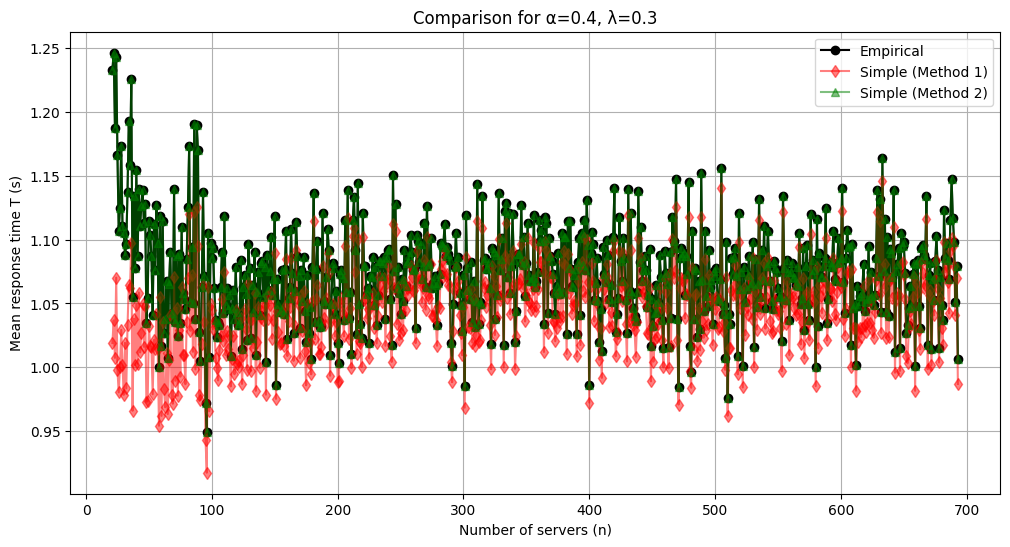

In [11]:
import matplotlib.pyplot as plt

# Assume investigate_df is loaded
# Assume mu_d (state‑dependent) and compute_T are already defined

alpha_target = 0.4
lam = 0.3

# Get simple μ dictionaries
mu1 = estimate_mu_n_alpha_1(investigate_df)
mu2 = estimate_mu_n_alpha_2(investigate_df, lam=lam)

# Empirical T
empirical_dict = {
    (int(row['active_servers_num']), row['alpha']): row['client_measured_time']
    for _, row in investigate_df.iterrows()
}

# Choose n range (e.g., all observed n)
n_values = sorted(set(n for (n, a) in mu1.keys() if a == alpha_target))

T_emp, T_state, T_simple1, T_simple2 = [], [], [], []

for n in n_values:
    T_emp.append(empirical_dict.get((n, alpha_target), np.nan))

    # State-dependent (requires extrapolate_mu_state)
    try:
        T_state.append(compute_T(n, lam, alpha_target, mu_d, extrapolate_mu_state))
    except Exception:
        T_state.append(np.nan)

    # Method 1
    mu = mu1.get((n, alpha_target))
    T_simple1.append(T_mmn(mu, lam, n) if mu is not None and not np.isnan(mu) else np.nan)

    # Method 2
    mu = mu2.get((n, alpha_target))
    T_simple2.append(T_mmn(mu, lam, n) if mu is not None and not np.isnan(mu) else np.nan)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(n_values, T_emp, 'ko-', label='Empirical')
# plt.plot(n_values, T_state, 'b-s', label='State‑dependent')
plt.plot(n_values, T_simple1, 'r-d', label='Simple (Method 1)', alpha=0.5)
plt.plot(n_values, T_simple2, 'g-^', label='Simple (Method 2)', alpha=0.5)
plt.xlabel('Number of servers (n)')
plt.ylabel('Mean response time T (s)')
plt.title(f'Comparison for α={alpha_target}, λ={lam}')
plt.grid(True)
plt.legend()
plt.show()

In [6]:
import numpy as np
import pandas as pd
from scipy.optimize import root_scalar

LAMBDA = 0.3

def erlang_c(n, rho):
    """Erlang-C probability that an arriving customer queues."""
    # rho = lambda / (n * mu)
    if rho >= 1.0:
        return 1.0
    # compute sum_{i=0}^{n-1} (n*rho)^i / i!
    terms = np.empty(n)
    terms[0] = 1.0
    for i in range(1, n):
        terms[i] = terms[i-1] * (n * rho) / i
    sum_terms = np.sum(terms)
    last_term = terms[-1] * (n * rho) / n   # (n*rho)^n / n!
    C = last_term / (sum_terms * (1 - rho) + last_term)
    return C

def mean_response_time(mu, n):
    """M/M/n mean system time."""
    if mu <= LAMBDA / n:
        return np.inf
    rho = LAMBDA / (n * mu)
    C = erlang_c(n, rho)
    T = 1.0 / mu + C / (n * mu - LAMBDA)
    return T

def solve_mu(target_T, n):
    """Return mu such that mean_response_time(mu, n) == target_T."""
    # Lower bound: just above stability limit
    low = LAMBDA / n + 1e-12
    # Find an upper bound by doubling until T(mu) < target_T
    high = 1.0
    while mean_response_time(high, n) > target_T:
        high *= 2.0
        if high > 1e6:  # safety valve
            raise ValueError("No valid mu found in reasonable range")
    # Bisection
    for _ in range(100):
        mid = (low + high) / 2.0
        T_mid = mean_response_time(mid, n)
        if T_mid > target_T:
            low = mid
        else:
            high = mid
        if high - low < 1e-12:
            break
    return (low + high) / 2.0

# Group by n and alpha, compute mean measured time
grouped = investigate_df.groupby(['active_servers_num', 'alpha'])['client_measured_time'].mean()

mu_dict = {}
for (n, alpha), T_mean in grouped.items():
    # Ensure n is int
    n = int(n)
    try:
        mu = solve_mu(T_mean, n)
        mu_dict[(n, alpha)] = mu
    except ValueError as e:
        print(f"Failed for n={n}, alpha={alpha}: {e}")

# mu_dict now contains the inferred service rates

In [7]:
import numpy as np
from functools import lru_cache

LAMBDA = 0.3  # arrival rate, fixed for your experiments

# ----------------------------------------------------------------------
# 1. Precomputed service rate dictionary
#    (assumes mu_dict is already built from data)
# ----------------------------------------------------------------------
# mu_dict = { (n, alpha): mu_value }   # provided externally

def get_mu(n, alpha):
    """Retrieve service rate μ(n,α) from the precomputed dictionary."""
    key = (n, alpha)
    if key not in mu_dict:
        raise ValueError(f"No service rate data for n={n}, alpha={alpha}")
    return mu_dict[key]

# ----------------------------------------------------------------------
# 2. Cached core quantities
# ----------------------------------------------------------------------
@lru_cache(maxsize=None)
def _cached_p0(n, alpha, lam):
    """Compute p0 once per (n, alpha) and cache it."""
    mu = get_mu(n, alpha)
    if n * mu <= lam:
        raise ValueError(f"System unstable: n*mu <= lambda for n={n}, alpha={alpha}")
    
    # Iteratively compute A_i = (λ/μ)^i / i!
    sum_A = 0.0
    A = 1.0  # A_0
    for i in range(1, n + 1):
        A *= lam / (i * mu)   # now A = A_i
        sum_A += A
    
    # term for i = n+1: A_n * λ / (n μ - λ)
    extra = A * lam / (n * mu - lam)
    return 1.0 / (1.0 + sum_A + extra)

@lru_cache(maxsize=None)
def _cached_mu(n, alpha):
    """Cache the service rate lookup."""
    return get_mu(n, alpha)

# ----------------------------------------------------------------------
# 3. Model functions (homogeneous service rates)
# ----------------------------------------------------------------------
def p0(n, alpha):
    """Steady-state probability of an empty system."""
    return _cached_p0(n, alpha, LAMBDA)

def pk(k, n, alpha):
    """Probability that exactly k customers are in the system."""
    if k < 0:
        return 0.0
    mu = _cached_mu(n, alpha)
    p0_val = _cached_p0(n, alpha, LAMBDA)
    
    # Compute (λ/μ)^k / k! iteratively
    if k <= n:
        term = 1.0
        for i in range(1, k + 1):
            term *= LAMBDA / (i * mu)
        return term * p0_val
    else:
        # For k > n: (λ/μ)^n / n!  *  (λ/(n μ))^(k-n)
        term = 1.0
        for i in range(1, n + 1):
            term *= LAMBDA / (i * mu)
        term *= (LAMBDA / (n * mu)) ** (k - n)
        return term * p0_val

def pQ(n, alpha):
    """Probability that an arriving customer has to queue (Erlang-C)."""
    mu = _cached_mu(n, alpha)
    p0_val = _cached_p0(n, alpha, LAMBDA)
    
    # Compute (λ/μ)^n / n!
    base = 1.0
    for i in range(1, n + 1):
        base *= LAMBDA / (i * mu)
    # Erlang-C: ( (λ/μ)^n / n! ) * (n μ) / (n μ - λ) * p0
    term = base * (n * mu) / (n * mu - LAMBDA)
    return term * p0_val

def L_N(n, alpha):
    """Partial sum of L: first n terms plus the extra term."""
    mu = _cached_mu(n, alpha)
    p0_val = _cached_p0(n, alpha, LAMBDA)
    
    # Sum_{k=1}^n k * (λ/μ)^k / k!
    sum_kA = 0.0
    A = 1.0   # A_0
    for k in range(1, n + 1):
        A *= LAMBDA / (k * mu)   # now A = (λ/μ)^k / k!
        sum_kA += k * A
    
    # Extra term: λ^(n+1) / ((n-1)! μ^n (n μ - λ))
    # Using relation: λ^(n+1) / ((n-1)! μ^n) = n * λ * (λ/μ)^n / n!
    # But easier: compute directly with iteration
    # (λ/μ)^n / n! = A_n (from last A)
    A_n = A
    extra = (n * LAMBDA * A_n) / (n * mu - LAMBDA)
    return (sum_kA + extra) * p0_val

def L_Q(n, alpha):
    """Mean number of customers in the queue."""
    mu = _cached_mu(n, alpha)
    p0_val = _cached_p0(n, alpha, LAMBDA)
    
    # Standard Erlang-C formula
    # Lq = ( (λ/μ)^n / n! ) * (n μ) / (n μ - λ)  *  (λ / (n μ - λ)) * p0
    # But we have already pQ = ( (λ/μ)^n / n! ) * (n μ) / (n μ - λ) * p0
    # So Lq = pQ * (λ / (n μ - λ))
    # However, the textbook formula is: Lq = (λ/μ)^n / n! * (n μ) / (n μ - λ) * (λ / (n μ - λ)) * p0
    # Which is exactly pQ * (λ / (n μ - λ)).
    # But to avoid recomputing pQ, we compute directly:
    base = 1.0
    for i in range(1, n + 1):
        base *= LAMBDA / (i * mu)
    # Lq = base * (n μ) / (n μ - λ) * (λ / (n μ - λ)) * p0
    term = base * (n * mu) / (n * mu - LAMBDA) * (LAMBDA / (n * mu - LAMBDA))
    return term * p0_val

def L_sys(n, alpha):
    """Mean total number of customers in the system (including in service)."""
    mu = _cached_mu(n, alpha)
    p0_val = _cached_p0(n, alpha, LAMBDA)
    
    # Sum_{k=1}^n k * (λ/μ)^k / k!
    sum_kA = 0.0
    A = 1.0
    for k in range(1, n + 1):
        A *= LAMBDA / (k * mu)
        sum_kA += k * A
    
    # Extra term for L_sys:
    # λ^(n+1) / ((n-1)! μ^n (n μ - λ)) * (1 + μ/(n μ - λ))
    # Using relation n * λ * A_n / (n μ - λ) * (1 + μ/(n μ - λ))
    A_n = A
    extra_factor = n * LAMBDA * A_n / (n * mu - LAMBDA)
    extra = extra_factor * (1.0 + mu / (n * mu - LAMBDA))
    
    return (sum_kA + extra) * p0_val

def T_sys(n, alpha):
    """Mean sojourn time (response time) in the system."""
    return L_sys(n, alpha) / LAMBDA

In [8]:
n, alpha = 50, 0.4
print(f"p0  = {p0(n, alpha):.6f}")
print(f"pQ  = {pQ(n, alpha):.6f}")
print(f"L_Q = {L_Q(n, alpha):.4f}")
print(f"L   = {L_sys(n, alpha):.4f}")
print(f"T   = {T_sys(n, alpha):.4f}")

p0  = 0.715803
pQ  = 0.000000
L_Q = 0.0000
L   = 0.3344
T   = 1.1145


In [9]:
def plot_T_for_alpha(alpha, experiment_df, smooth=True, window_length=51, polyorder=3, max_index=150):
    alpha_df = experiment_df[experiment_df['alpha'] == alpha]
    if alpha_df.empty:
        raise ValueError(f"No experimental data for alpha={alpha}")

    # Assuming data is sorted by active_servers_num
    x_exp = alpha_df['active_servers_num'].values[:max_index]
    y_exp_raw = alpha_df['client_measured_time'].values[:max_index]

    # Analytical T for each n in x_exp
    T_vals = np.array([T_sys(n, alpha) for n in x_exp])  # using T_sys, which uses mu_dict

    # Plot
    plt.figure(figsize=(10, 5))
    if smooth:
        original = savgol_filter(y_exp_raw, window_length, polyorder)
        T_vals_smooth = savgol_filter(T_vals, window_length, polyorder)
        plt.plot(x_exp, y_smooth, 'o-', label=f'Experiment (α={alpha})')
        plt.plot(x_exp, T_vals_smooth, '-', label='Model prediction')
        
    else:
        plt.plot(x_exp, y_exp_raw, 'o-', label=f'Experiment (α={alpha})')
        plt.plot(x_exp, T_vals, '-', label='Model prediction')

    plt.xlabel('Number of active servers (n)')
    plt.ylabel('Request time in system (sec)')
    plt.title(f'Model vs. experiment for α = {alpha}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

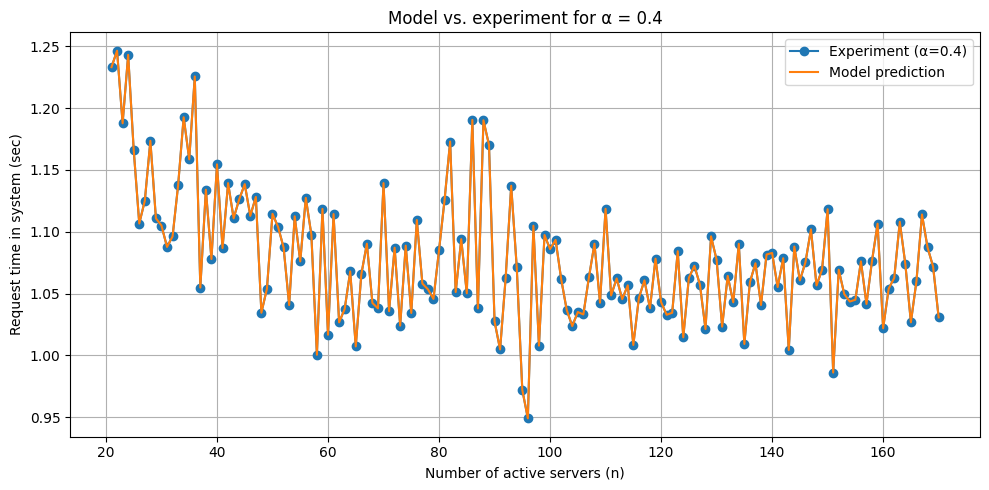

In [10]:
plot_T_for_alpha(0.4, investigate_df, max_index=150, smooth=False)